# Day 1: Energy Mix

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
platemap_path = "../1-design/20250512-OPWS-platemap.tsv"
data_path = "../2-data/20250512-185553-pure-timecourse-gfp-pure-sm-mix-biotek-cdk.txt"

data, platemap = pr.load_platereader_data(data_path, platemap_path)

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

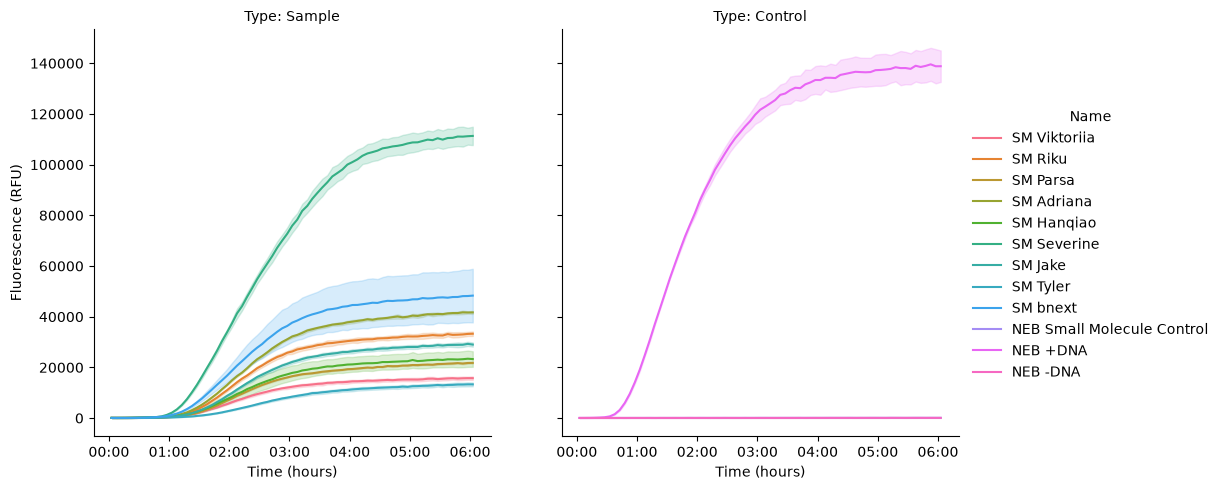

In [4]:
#| label: fig:day1-kinetics

ctrl_data = data[data["Type"]=="Control"]
exp_data = data[data["Type"] !="Standard"]

pr.plot_curves(exp_data, col="Type");

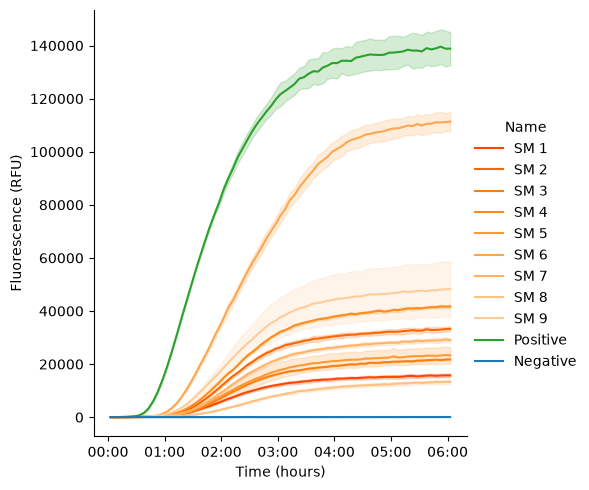

In [5]:
#| label: fig:day1-kinetics-all

exp_data = data[data["Type"] !="Standard"]

names_to_remove = ['NEB Small Molecule Control']

replace_dict = {'SM Viktoriia':'SM 1',
                'SM Riku':'SM 2',
                'SM Parsa':'SM 3',
                'SM Adriana':'SM 4',
                'SM Hanqiao':'SM 5',
                'SM Severine':'SM 6',
                'SM Jake':'SM 7',
                'SM Tyler':'SM 8',
                'SM bnext':'SM 9',
                'NEB +DNA':'Positive',
                'NEB -DNA':'Negative'
               }

custom_order = ['no Folinic Acid', 
                'Folinic Acid', 
                'Folinic Acid + MTHFS', 
                '5,10-methenyl-THF', 
                'Positive', 
                'Negative']

color_map = {'SM 1':'#ff4500',
             'SM 2':'#ff6600',
             'SM 3':'#ff7f0e',
             'SM 4':'#ff8c1a',
             'SM 5':'#ff9933',
             'SM 6':'#ffa64d',
             'SM 7':'#ffb366',
             'SM 8':'#ffc080',
             'SM 9':'#ffcc99',
             'Positive':'#2ca02c',
             'Negative':'#1f77b4'
            }

data_drop = exp_data.drop(exp_data[exp_data['Name'].isin(names_to_remove)].index)
data_drop['Name'] = data_drop['Name'].replace(replace_dict)

pr.plot_curves(data_drop, palette=color_map);

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.



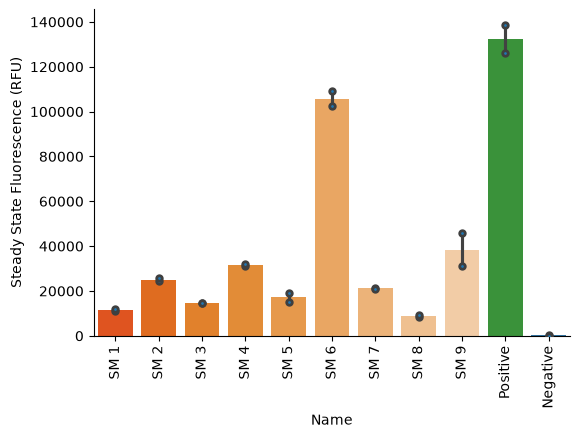

In [6]:
#| label: fig:day1-endpoint

ctrl_data = data[data["Type"]=="Control"]
exp_data = data[data["Type"] !="Standard"]

pr.plot_steadystate(data_drop, palette=color_map);

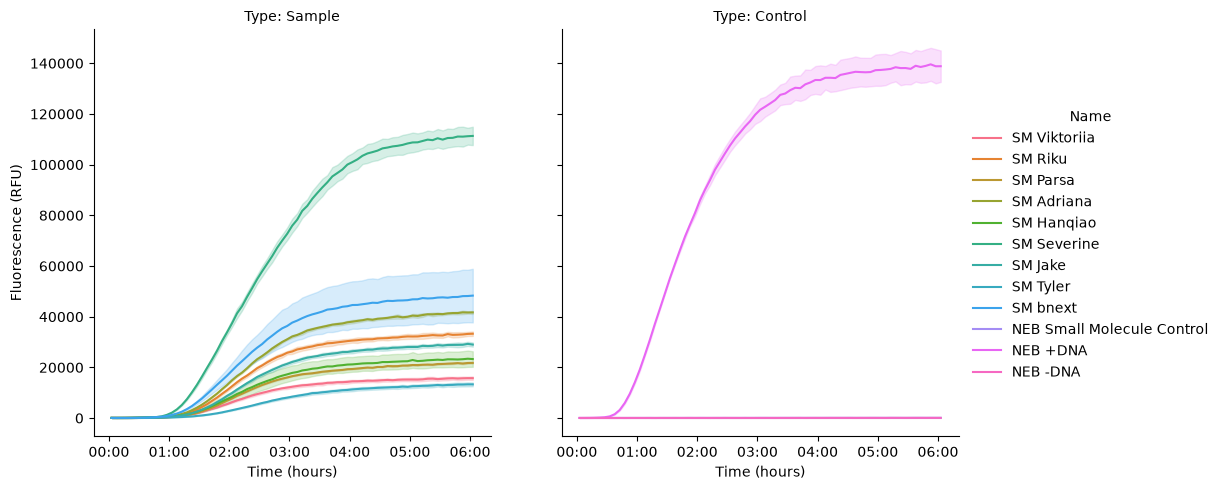

In [7]:
#| label: fig:day1-kinetics
ctrl_data = data[data["Type"]=="Control"]
exp_data = data[data["Type"] !="Standard"]

pr.plot_curves(exp_data, col="Type");

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x30b49a990>,
                                                      Velocity            \
                                                          Time      Data   
 Name                       Read                                           
 NEB +DNA                   GFP-Gext 0 days 01:39:31.430706215  69735.45   
 NEB -DNA                   GFP-Gext           0 days 06:02:43     80.60   
 NEB Small Molecule Control GFP-Gext           0 days 00:00:00     45.84   
 SM Adriana                 GFP-Gext 0 days 02:16:26.780322514  16657.90   
 SM Hanqiao                 GFP-Gext 0 days 02:16:12.445959077   9090.72   
 SM Jake                    GFP-Gext 0 days 02:17:03.604461910  11132.98   
 SM Parsa                   GFP-Gext 0 days 02:13:52.335808571   7669.92   
 SM Riku                    GFP-Gext 0 days 02:12:43.366050645  13209.29   
 SM Severine                GFP-Gext 0 days 02:26:02.691293917  55688.77   
 SM Tyler                   GFP-Gext 0 day

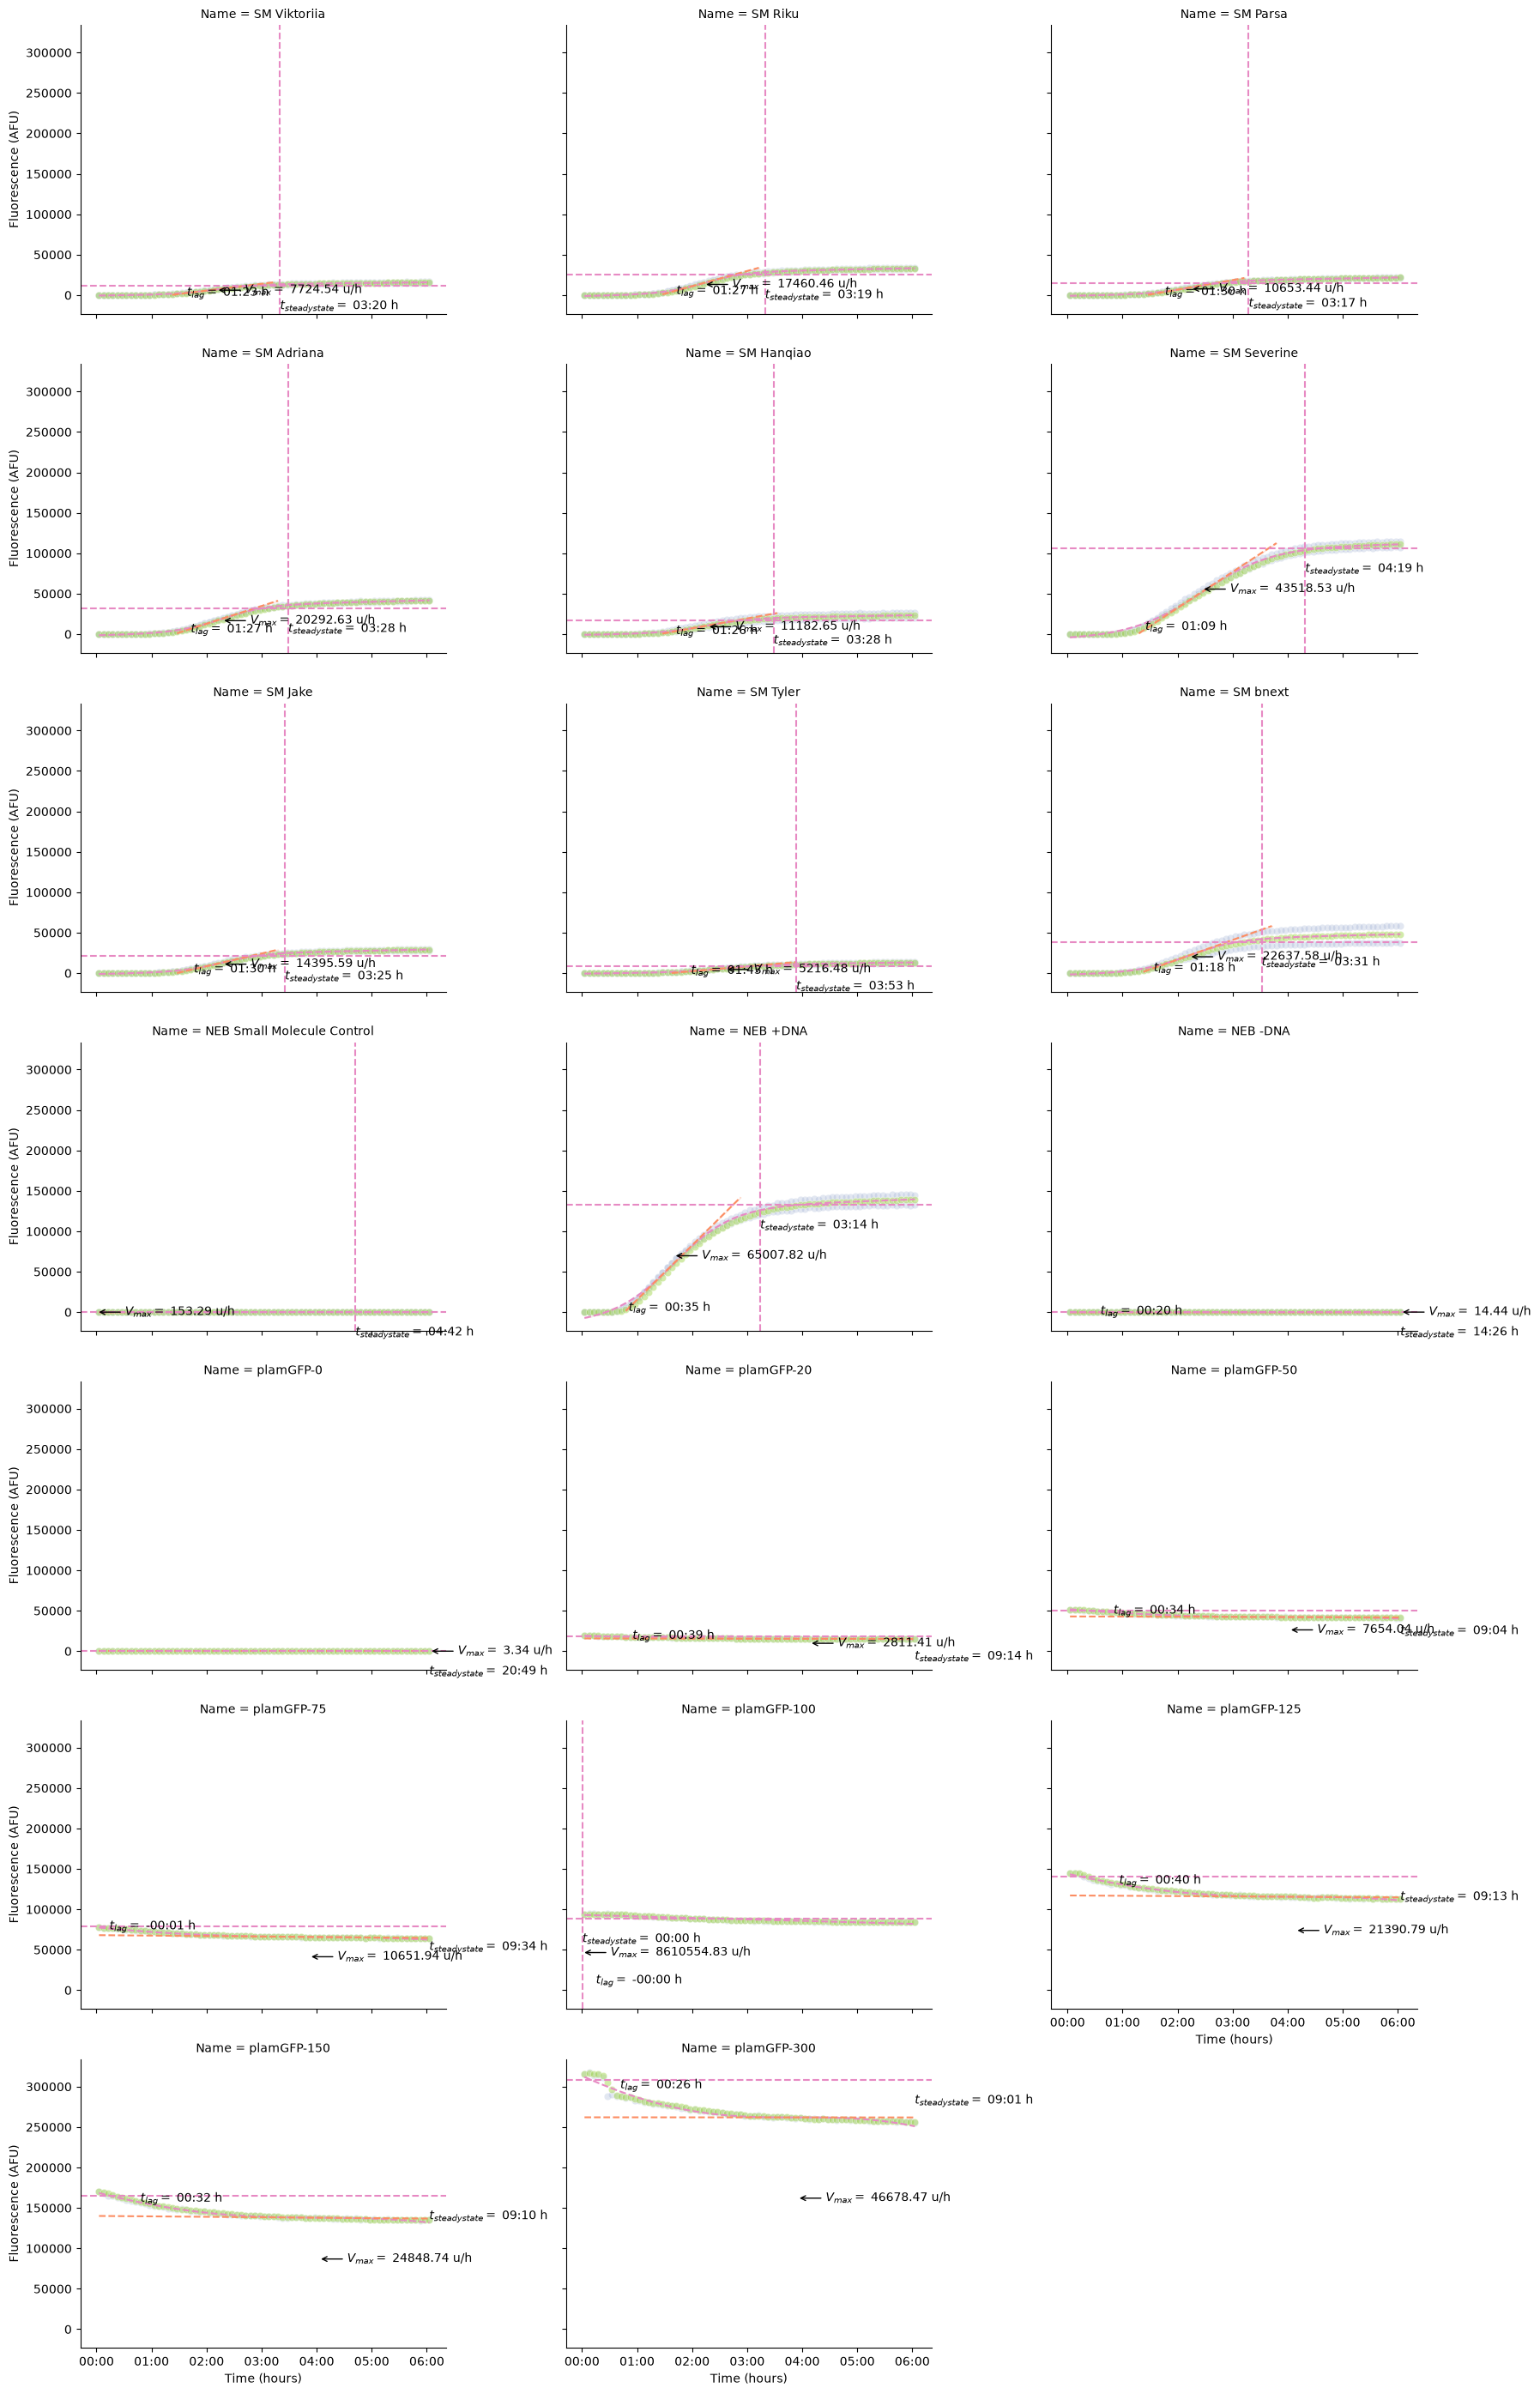

In [8]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [9]:
pr.kinetic_analysis(data)

Velocity            \
                                                              Time      Data   
Name                       Read     Well                                       
SM Viktoriia               GFP-Gext A1   0 days 02:11:00.790427860   5860.80   
SM Riku                    GFP-Gext A3   0 days 02:13:22.909951707  12757.42   
SM Parsa                   GFP-Gext A5   0 days 02:14:35.276140186   7638.78   
SM Adriana                 GFP-Gext A7   0 days 02:16:40.192708137  16350.24   
SM Hanqiao                 GFP-Gext A9   0 days 02:22:30.845072956   8054.05   
SM Severine                GFP-Gext A11  0 days 02:25:47.213813186  57458.37   
SM Jake                    GFP-Gext A13  0 days 02:16:28.696064217  11339.25   
SM Tyler                   GFP-Gext A15  0 days 02:35:56.492720592   4346.64   
SM bnext                   GFP-Gext A17  0 days 02:14:28.876725049  24200.04   
NEB Small Molecule Control GFP-Gext A19            0 days 00:00:00     63.01   
NEB +DNA                   GFP-Gext A21  0 days 01:41:24.858259260  72982.89   
NEB -DNA                   GFP-Gext A23            0 days 06:02:43     84.32   
SM Viktoriia               GFP-Gext B1   0 days 02:09:44.576258151   6333.49   
SM Riku                    GFP-Gext B3   0 days 02:12:03.822149584  13661.15   
SM Parsa                   GFP-Gext B5   0 days 02:13:09.395476957   7701.07   
SM Adriana                 GFP-Gext B7   0 days 02:16:13.367936892  16965.56   
SM Hanqiao                 GFP-Gext B9   0 days 02:09:54.046845198  10127.38   
SM Severine                GFP-Gext B11  0 days 02:26:18.168774648  53919.16   
SM Jake                    GFP-Gext B13  0 days 02:17:38.512859604  10926.70   
SM Tyler                   GFP-Gext B15  0 days 02:35:56.260218566   4804.38   
SM bnext                   GFP-Gext B17  0 days 02:10:06.368159942  16287.15   
NEB Small Molecule Control GFP-Gext B19            0 days 00:00:00     28.68   
NEB +DNA                   GFP-Gext B21  0 days 01:37:38.003153170  66488.02   
NEB -DNA                   GFP-Gext B23            0 days 06:02:43     76.88   
plamGFP-0                  GFP-Gext D1             0 days 06:02:43     33.58   
plamGFP-20                 GFP-Gext D3   0 days 04:07:43.265912250   9755.52   
plamGFP-50                 GFP-Gext D5   0 days 04:01:04.590620338  26331.68   
plamGFP-75                 GFP-Gext D7   0 days 03:51:34.540019910  41367.21   
plamGFP-100                GFP-Gext D9             0 days 00:00:00  46551.58   
plamGFP-125                GFP-Gext D11  0 days 04:08:02.483376100  73897.64   
plamGFP-150                GFP-Gext D13  0 days 04:02:02.504050249  86842.09   
plamGFP-300                GFP-Gext D15  0 days 03:54:26.802272520 162083.24   

                                                     \
                                                Max   
Name                       Read     Well              
SM Viktoriia               GFP-Gext A1      7412.13   
SM Riku                    GFP-Gext A3     16888.35   
SM Parsa                   GFP-Gext A5     10617.31   
SM Adriana                 GFP-Gext A7     20008.42   
SM Hanqiao                 GFP-Gext A9      9157.95   
SM Severine                GFP-Gext A11    45064.64   
SM Jake                    GFP-Gext A13    14917.38   
SM Tyler                   GFP-Gext A15     4903.45   
SM bnext                   GFP-Gext A17    27500.46   
NEB Small Molecule Control GFP-Gext A19       10.01   
NEB +DNA                   GFP-Gext A21    65708.57   
NEB -DNA                   GFP-Gext A23       16.93   
SM Viktoriia               GFP-Gext B1      8036.95   
SM Riku                    GFP-Gext B3     18032.57   
SM Parsa                   GFP-Gext B5     10689.58   
SM Adriana                 GFP-Gext B7     20576.83   
SM Hanqiao                 GFP-Gext B9     13207.35   
SM Severine                GFP-Gext B11    41972.43   
SM Jake                    GFP-Gext B13    13873.80   
SM Tyler                   GFP-Gext B15     552